<a href="https://colab.research.google.com/github/munhyunsik/ML/blob/ML/%EA%B8%B0%EB%A7%90%EA%B3%A0%EC%82%AC20250613.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **기말고사(20250613)**
학번 :  2020140007           
성명 : 문현식

# **문제 1) ANN Backpropagation**

In [428]:
# Back-propagation of ANN with numpy
import numpy as np
import matplotlib.pyplot as plt

# Data Generation
np.random.seed(0)
num_samples = 300

x1 = np.random.uniform(0, 1, num_samples)
x2 = np.random.uniform(0, 1, num_samples)
x3 = np.random.uniform(0, 1, num_samples)

# Target
y = 3 * x1 - 2 * x2 + x3

In [429]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

In [430]:
Input = np.column_stack((x1, x2, x3))

input_layer_size = 3
hidden_layer_size = 4
output_layer_size = 1

W1 = np.random.randn(hidden_layer_size, input_layer_size)
b1 = np.random.randn(hidden_layer_size)
W2 = np.random.randn(output_layer_size, hidden_layer_size)
b2 = np.random.randn(output_layer_size)

alpha = 0.001
epochs = 2500

MSE_list, MAPE_list = [], []

Epoch 0 - MSE: 0.595157, MAPE: 232.26%
Epoch 10 - MSE: 0.515664, MAPE: 277.03%
Epoch 20 - MSE: 0.457885, MAPE: 260.81%
Epoch 30 - MSE: 0.390813, MAPE: 240.17%
Epoch 40 - MSE: 0.317914, MAPE: 215.04%
Epoch 50 - MSE: 0.246102, MAPE: 186.71%
Epoch 60 - MSE: 0.181845, MAPE: 157.10%
Epoch 70 - MSE: 0.129018, MAPE: 128.25%
Epoch 80 - MSE: 0.088679, MAPE: 101.52%
Epoch 90 - MSE: 0.059739, MAPE: 78.64%
Epoch 100 - MSE: 0.039974, MAPE: 60.71%
Epoch 110 - MSE: 0.026944, MAPE: 47.06%
Epoch 120 - MSE: 0.018545, MAPE: 36.52%
Epoch 130 - MSE: 0.013188, MAPE: 28.34%
Epoch 140 - MSE: 0.009778, MAPE: 24.00%
Epoch 150 - MSE: 0.007596, MAPE: 21.42%
Epoch 160 - MSE: 0.006186, MAPE: 20.62%
Epoch 170 - MSE: 0.005263, MAPE: 20.13%
Epoch 180 - MSE: 0.004650, MAPE: 19.84%
Epoch 190 - MSE: 0.004236, MAPE: 19.66%
Epoch 200 - MSE: 0.003953, MAPE: 19.59%
Epoch 210 - MSE: 0.003755, MAPE: 19.50%
Epoch 220 - MSE: 0.003615, MAPE: 19.46%
Epoch 230 - MSE: 0.003512, MAPE: 19.60%
Epoch 240 - MSE: 0.003436, MAPE: 19.70%
Ep

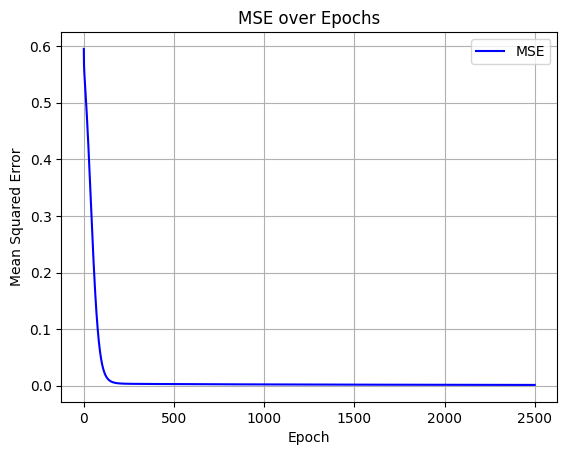

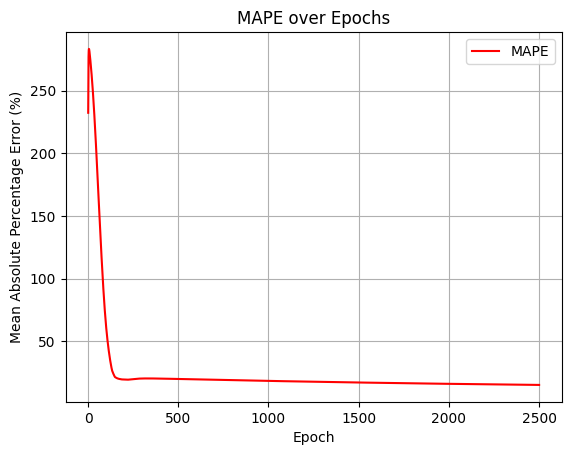

In [431]:
for epoch in range(epochs):
    MSE, MAPE = 0, 0
    for i in range(num_samples):
        X = Input[i]

        Z_tilde = W1 @ X.reshape(-1, 1) + b1.reshape(-1, 1)
        Z = sigmoid(Z_tilde)
        y_pred = W2 @ Z + b2.reshape(-1, 1)


        error = y_pred - y[i]
        MSE += 0.5 * error ** 2
        MAPE += np.abs(error / y[i]) * 100 if y[i] != 0 else 0


        dJdY = error
        dJdW2 = dJdY @ Z.T
        dJdb2 = dJdY

        dJdZ = W2.T @ dJdY
        dZ_tilde = sigmoid_derivative(Z_tilde)
        dJdZ_tilde = dJdZ * dZ_tilde

        dJdW1 = dJdZ_tilde @ X.reshape(1, -1)
        dJdb1 = dJdZ_tilde.reshape(-1)


        W2 -= alpha * dJdW2
        b2 -= alpha * dJdb2.flatten()

        W1 -= alpha * dJdW1
        b1 -= alpha * dJdb1

    MSE /= num_samples
    MAPE /= num_samples
    MSE_list.append(np.squeeze(MSE))
    MAPE_list.append(np.squeeze(MAPE))

    if epoch % 10 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch} - MSE: {np.squeeze(MSE):.6f}, MAPE: {np.squeeze(MAPE):.2f}%")


plt.figure()
plt.plot(np.arange(1, epochs+1), MSE_list, label='MSE', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('MSE over Epochs')
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(np.arange(1, epochs+1), MAPE_list, label='MAPE', color='red')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Percentage Error (%)')
plt.title('MAPE over Epochs')
plt.grid(True)
plt.legend()
plt.show()

# **문제 2) CNN**
- Data
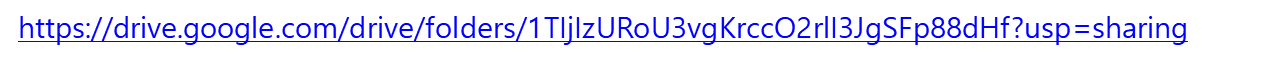

In [432]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [433]:
# 0,1,2,3,4, and 5 finger image data set

train_x = np.load('/content/Finger_train_img.npy')
train_y = np.load('/content/Finger_train_label.npy')

test_x = np.load('/content/Finger_test_img.npy')
test_y = np.load('/content/Finger_test_label.npy')

In [434]:
train_x.shape

(900, 100, 100, 1)

In [435]:
train_y.shape

(900, 6)

In [436]:
train_x = train_x.reshape((train_x.shape[0], 100, 100, 1))
test_x = test_x.reshape((test_x.shape[0], 100, 100, 1))

In [437]:
input_h = 100
input_w = 100
input_ch = 1

k1_h = 3
k1_w = 3
k1_ch = 32
p1_h = 2
p1_w = 2

k2_h = 3
k2_w = 3
k2_ch = 64
p2_h = 2
p2_w = 2

k3_h = 3
k3_w = 3
k3_ch = 128
p3_h = 2
p3_w = 2

conv_result_size = 13 * 13 * 128
n_hidden = 100
n_output = 6

In [438]:
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

weights = {
    'conv1' : tf.Variable(tf.random.normal([k1_h, k1_w, input_ch, k1_ch], stddev = 0.1)),
    'conv2' : tf.Variable(tf.random.normal([k2_h, k2_w, k1_ch, k2_ch], stddev = 0.1)),
    'conv3' : tf.Variable(tf.random.normal([k3_h, k3_w, k2_ch, k3_ch], stddev = 0.1)),
    'hidden' : tf.Variable(tf.random.normal([conv_result_size, n_hidden], stddev = 0.1)),
    'output' : tf.Variable(tf.random.normal([n_hidden, n_output], stddev = 0.1))
}

biases = {
    'conv1' : tf.Variable(tf.random.normal([k1_ch], stddev = 0.1)),
    'conv2' : tf.Variable(tf.random.normal([k2_ch], stddev = 0.1)),
    'conv3' : tf.Variable(tf.random.normal([k3_ch], stddev = 0.1)),
    'hidden' : tf.Variable(tf.random.normal([n_hidden], stddev = 0.1)),
    'output' : tf.Variable(tf.random.normal([n_output], stddev = 0.1))
}

x = tf.placeholder(shape=[None, input_h, input_w, input_ch], dtype=tf.float32)
y = tf.placeholder(shape=[None, n_output], dtype=tf.float32)

In [439]:
def net(x, weights, biases):

    conv1 = tf.nn.conv2d(x, weights['conv1'], strides = [1,1,1,1], padding = 'SAME')
    conv1 = tf.nn.relu(tf.add(conv1, biases['conv1']))
    maxp1 = tf.nn.max_pool(conv1, ksize=[1,p1_h,p1_w,1], strides=[1,p1_h,p1_w,1], padding='VALID')

    conv2 = tf.nn.conv2d(maxp1, weights['conv2'], strides=[1,1,1,1], padding='SAME')
    conv2 = tf.nn.relu(tf.add(conv2, biases['conv2']))
    maxp2 = tf.nn.max_pool(conv2, ksize=[1, p2_h, p2_w, 1], strides=[1, p2_h, p2_w, 1], padding='VALID')

    conv3 = tf.nn.conv2d(maxp2, weights['conv3'], strides=[1,1,1,1], padding='SAME')
    conv3 = tf.nn.relu(tf.add(conv3, biases['conv3']))
    maxp3 = tf.nn.max_pool(conv3, ksize=[1, p3_h, p3_w, 1], strides=[1, p3_h, p3_w, 1], padding='SAME')

    maxp3_flatten = tf.reshape(maxp3, [-1, conv_result_size])

    hidden = tf.add(tf.matmul(maxp3_flatten, weights['hidden']), biases['hidden'])
    hidden = tf.nn.relu(hidden)
    output = tf.add(tf.matmul(hidden, weights['output']), biases['output'])

    return output


In [498]:
LR = 0.0002
pred = net(x, weights, biases)
loss = tf.nn.softmax_cross_entropy_with_logits(logits = pred, labels = y)
loss = tf.reduce_mean(loss)

optm = tf.train.AdamOptimizer(learning_rate=LR).minimize(loss)

Iter : 0
Train Loss : 886.903564453125
Cost : 1047.494873046875
Iter : 250
Train Loss : 4.634638786315918
Cost : 14.801839828491211
Iter : 500
Train Loss : 0.2697916328907013
Cost : 6.459413051605225
Iter : 750
Train Loss : 6.903486337250797e-06
Cost : 8.876445770263672
Iter : 1000
Train Loss : 0.03838324919342995
Cost : 8.500988006591797
Iter : 1250
Train Loss : 6.028658390045166
Cost : 3.8544843196868896
Iter : 1500
Train Loss : 0.0
Cost : 16.8326358795166
Iter : 1750
Train Loss : 1.430510998545742e-08
Cost : 9.206942558288574
Iter : 2000
Train Loss : 0.0
Cost : 13.368809700012207
Iter : 2250
Train Loss : 0.0
Cost : 5.181944370269775
Iter : 2500
Train Loss : 1.192092558000013e-08
Cost : 9.943513870239258
Iter : 2750
Train Loss : 0.0
Cost : 8.183802604675293
Iter : 3000
Train Loss : 1.280266701542132e-06
Cost : 3.5780298709869385
Iter : 3250
Train Loss : 0.0
Cost : 7.397494316101074
Iter : 3500
Train Loss : 0.0
Cost : 8.412060737609863
Iter : 3750
Train Loss : 0.0
Cost : 6.38394594192

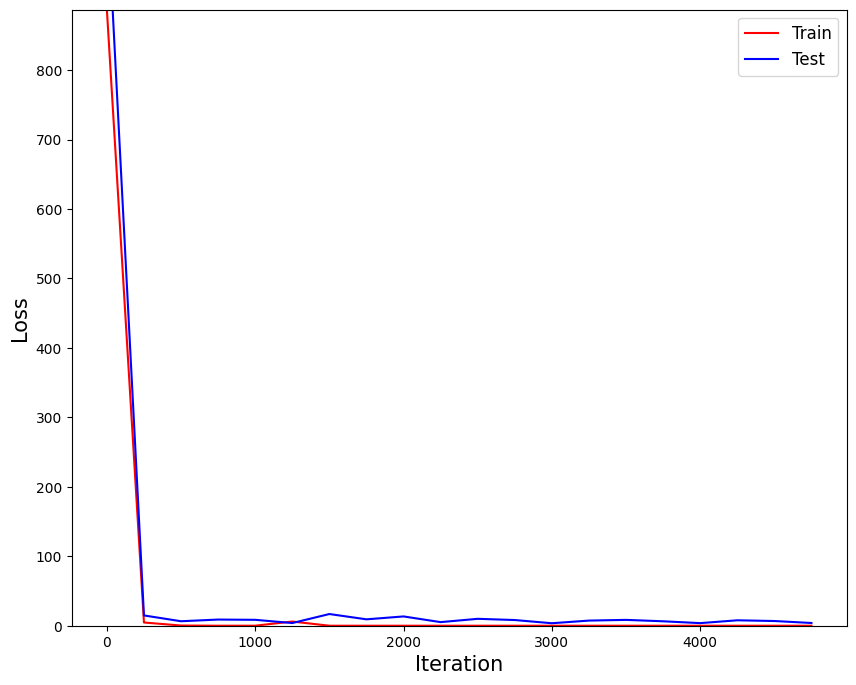

In [499]:
n_batch = 50
n_iter = 5000
n_prt = 250

sess = tf.Session()
sess.run(tf.global_variables_initializer())

loss_record_train = []
loss_record_test = []
for epoch in range(n_iter):

    batch_indices = np.random.choice(train_x.shape[0], size=n_batch, replace=False)
    batch_x = train_x[batch_indices]
    batch_y = train_y[batch_indices]

    batch_x = np.reshape(batch_x, (-1, 100, 100, 1))
    batch_y = train_y[batch_indices]

    sess.run(optm, feed_dict={x:batch_x, y:batch_y})

    if epoch % n_prt == 0:

        test_batch_indices = np.random.choice(test_x.shape[0], size=n_batch, replace=False)
        test_batch_x = test_x[test_batch_indices]
        test_batch_y = test_y[test_batch_indices]

        test_batch_x = test_batch_x.reshape((n_batch, input_h, input_w, input_ch))
        test_batch_y = test_y[test_batch_indices]
        c1 = sess.run(loss, feed_dict={x: batch_x, y: batch_y})
        c2 = sess.run(loss, feed_dict={x: test_batch_x, y: test_batch_y})

        loss_record_train.append(c1)
        loss_record_test.append(c2)
        print("Iter : {}".format(epoch))
        print("Train Loss : {}".format(c1))
        print("Cost : {}".format(c2))

plt.figure(figsize = (10,8))
plt.plot(np.arange(len(loss_record_train))*n_prt, loss_record_train, 'r', label = 'Train')
plt.plot(np.arange(len(loss_record_test))*n_prt, loss_record_test, 'b', label = 'Test')
plt.xlabel('Iteration', fontsize = 15)
plt.ylabel('Loss', fontsize = 15)
plt.legend(fontsize = 12)
plt.ylim([0, np.max(loss_record_train)])
plt.show()

In [510]:
test_batch_indices = np.random.choice(test_x.shape[0], size=n_batch, replace=False)
test_batch_x = test_x[test_batch_indices]
test_batch_y = test_y[test_batch_indices]

test_batch_x = test_batch_x.reshape((n_batch, input_h, input_w, input_ch))
test_batch_y = test_y[test_batch_indices]

my_pred = sess.run(pred, feed_dict={x: test_batch_x.reshape(-1, 100, 100, 1)})
my_pred = np.argmax(my_pred, axis=1)

labels = np.argmax(test_batch_y, axis=1)

accr = np.mean(np.equal(my_pred, labels))
print("Accuracy : {}".format(accr*100))

Accuracy : 94.0


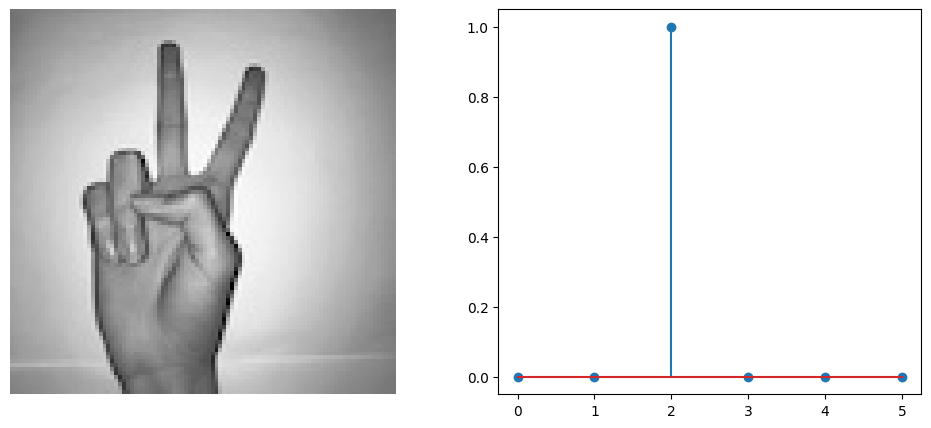

Prediction : 2
Probability : [0. 0. 1. 0. 0. 0.]


In [511]:
n_batch = 1
test_batch_indices = np.random.choice(test_x.shape[0], size=n_batch, replace=False)
test_batch_x = test_x[test_batch_indices]
test_batch_y = test_y[test_batch_indices]

test_batch_x = test_batch_x.reshape((n_batch, input_h, input_w, input_ch))
test_batch_y = tf.keras.utils.to_categorical(test_batch_y, num_classes=10)

logits = sess.run(tf.nn.softmax(pred), feed_dict={x: test_batch_x.reshape(-1, 100, 100, 1)})
predict = np.argmax(logits)

plt.figure(figsize = (12, 5))
plt.subplot(1,2,1)
plt.imshow(test_batch_x.reshape(100, 100), 'gray')
plt.axis('off')
plt.subplot(1,2,2)
plt.stem(logits.ravel())
plt.show()

np.set_printoptions(precision = 2, suppress = True)
print('Prediction : {}'.format(predict))
print('Probability : {}'.format(logits.ravel()))

# **문제 3) K-means clustering**

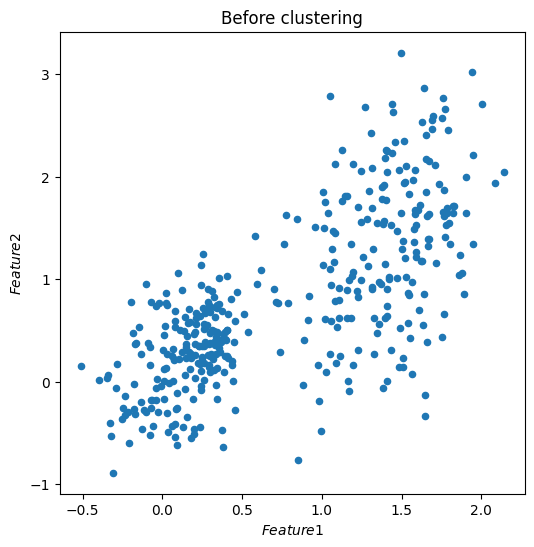

In [413]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# 각 데이터를 (100, 2) 모양으로 정확히 생성
data1 = np.stack((np.random.normal(0, 0.2, 100), np.random.normal(0.0, 0.4, 100)), axis=1)
data2 = np.stack((np.random.normal(1.2, 0.3, 100), np.random.normal(1.1, 0.7, 100)), axis=1)
data3 = np.stack((np.random.normal(1.6, 0.2, 100), np.random.normal(1.8, 0.7, 100)), axis=1)
data4 = np.stack((np.random.normal(0.3, 0.1, 100), np.random.normal(0.5, 0.3, 100)), axis=1)

# 전체 400개 (100 * 4) 데이터로 합침
X = np.vstack([data1, data2, data3, data4])

# 시각화
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], s=20)
plt.title("Before clustering")
plt.xlabel(r'$Feature1$')
plt.ylabel(r'$Feature2$')
plt.show()


In [414]:
N, num_features = X.shape[0], X.shape[1]


In [415]:
def initialize_centroids(K, num_features):
    return np.zeros((K, num_features))

In [416]:
def update_cluster(X, centroids):
    # Assign clusters
    r = np.zeros((N,K)) # Initialize r as a zero matrix  (300, 4)
    distances = np.zeros((N,K))
    for i in range(N):
        for k in range(K):
            distances[i,k] = np.sum((X[i] - centroids[k])**2)
    nearest_centroid = np.argmin(distances, axis=1)
    # Assign 1 to the nearest cluster in r
    r[np.arange(N), nearest_centroid] = 1
    return r, nearest_centroid, distances

In [417]:
def update_centroid(X, r, centroids):
    new_centroids = np.zeros((K, num_features))
    for k in range(K):
        # Check if the cluster has any points assigned
        if np.sum(r[:, k]) > 0:
            # Update centroid
            for i in range(N):
                new_centroids[k] += r[i,k]*X[i]
            new_centroids[k] /= np.sum(r[:,k])
        else:
            new_centroids[k] = centroids[k]
    return new_centroids

In [418]:
def kmeans(X, K, max_iters=100, epsilon=1e-6):
    N = X.shape[0]
    # Initialize the centroids to zero
    centroids = initialize_centroids(K, num_features)
    J = 1e6 # Arbitrary large number
    for iter in range(max_iters):
        r, nearest_centroid, distances = update_cluster(X,centroids)
        new_centroids = update_centroid(X, r, centroids)
        new_J = 0
        for i in range(N):
            for k in range(K):
                new_J += r[i,k]*distances[i,k]
        if np.abs((new_J - J)/new_J) < epsilon:
            break
        centroids = new_centroids
        J = new_J
        print('Iter :', iter, 'J : ', J)
    return nearest_centroid, centroids

nearest_centroid, centroids = kmeans(X, K)

Iter : 0 J :  927.8306088889756
Iter : 1 J :  311.6799924252245
Iter : 2 J :  183.64690105318968
Iter : 3 J :  129.90046357629475
Iter : 4 J :  117.11457689967048
Iter : 5 J :  112.36249884648484
Iter : 6 J :  106.03016801189159
Iter : 7 J :  95.67019202818075
Iter : 8 J :  78.50274586880711
Iter : 9 J :  72.77020643033605
Iter : 10 J :  71.88885310263639
Iter : 11 J :  71.6210889986698
Iter : 12 J :  71.59758433012819
Iter : 13 J :  71.58109840441202
Iter : 14 J :  71.49497233341026
Iter : 15 J :  71.47121991070301
Iter : 16 J :  71.46190215559969
Iter : 17 J :  71.45833626184569


Iter : 0 J :  927.8306088889756
Iter : 1 J :  448.22685564634776
Iter : 0 J :  927.8306088889756
Iter : 1 J :  311.6799924252245
Iter : 2 J :  187.80475632104086
Iter : 3 J :  160.2476714180911
Iter : 4 J :  156.00124682180197
Iter : 5 J :  154.78522753622684
Iter : 6 J :  154.42145620783418
Iter : 7 J :  154.32787720406262
Iter : 0 J :  927.8306088889756
Iter : 1 J :  311.6799924252245
Iter : 2 J :  183.64690105318968
Iter : 3 J :  131.94582642678495
Iter : 4 J :  123.17416066580795
Iter : 5 J :  121.63250777760818
Iter : 6 J :  121.2574856547107
Iter : 7 J :  120.5960725670326
Iter : 8 J :  119.7912300199831
Iter : 9 J :  118.93242691153608
Iter : 10 J :  118.09420994528264
Iter : 11 J :  117.74417315945038
Iter : 12 J :  117.45197979283799
Iter : 13 J :  116.78545362282456
Iter : 14 J :  115.85903390569511
Iter : 15 J :  114.01599903552501
Iter : 16 J :  110.77435539686535
Iter : 17 J :  105.46540698996237
Iter : 18 J :  101.43974844687254
Iter : 19 J :  99.18365153947751
Iter : 20 

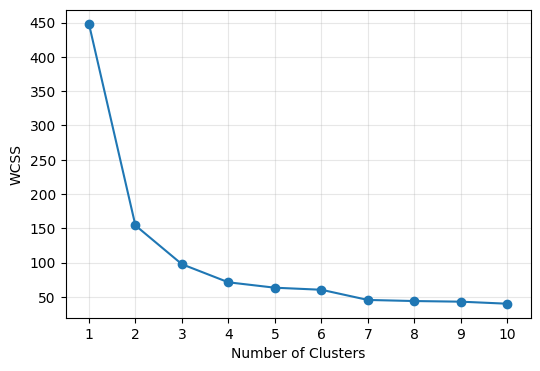

In [419]:
wcss = []

for k in range(1, 11):
    K = k
    nearest_centroid, centroids = kmeans(X, K)

    wcss_k = 0
    for i in range(X.shape[0]):
        c = centroids[nearest_centroid[i]]
        wcss_k += np.sum((X[i] - c)**2)

    wcss.append(wcss_k)


plt.figure(figsize = (6, 4))
plt.plot(range(1, 11), wcss, 'o-')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.xticks(np.arange(1, 11))
plt.xlim([0.5, 10.5])
plt.grid(alpha = 0.3)
plt.show()

In [420]:
# 최적의 K = 4 선택
K = 4

Iter : 0 J :  927.8306088889756
Iter : 1 J :  311.6799924252245
Iter : 2 J :  183.64690105318968
Iter : 3 J :  129.90046357629475
Iter : 4 J :  117.11457689967048
Iter : 5 J :  112.36249884648484
Iter : 6 J :  106.03016801189159
Iter : 7 J :  95.67019202818075
Iter : 8 J :  78.50274586880711
Iter : 9 J :  72.77020643033605
Iter : 10 J :  71.88885310263639
Iter : 11 J :  71.6210889986698
Iter : 12 J :  71.59758433012819
Iter : 13 J :  71.58109840441202
Iter : 14 J :  71.49497233341026
Iter : 15 J :  71.47121991070301
Iter : 16 J :  71.46190215559969
Iter : 17 J :  71.45833626184569


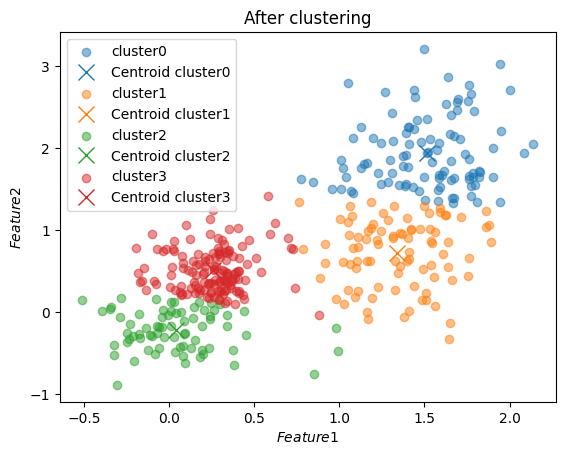

In [421]:
nearest_centroid, centroids = kmeans(X, K)

plt.figure(1)
for i in range(K):
    plt.scatter(X[nearest_centroid == i, 0], X[nearest_centroid == i, 1], alpha = 0.5, label=f'cluster{i}')
    plt.plot(centroids[i, 0], centroids[i, 1], 'x', markersize=12, label=f'Centroid cluster{i}')
plt.legend()
plt.title("After clustering")
plt.xlabel(r'$Feature1$')
plt.ylabel(r'$Feature2$')
plt.show()

Iter : 0 J :  927.8306088889756
Iter : 1 J :  311.6799924252245
Iter : 2 J :  183.64690105318968
Iter : 3 J :  129.90046357629475
Iter : 4 J :  117.11457689967048
Iter : 5 J :  112.36249884648484
Iter : 6 J :  106.03016801189159
Iter : 7 J :  95.67019202818075
Iter : 8 J :  78.50274586880711
Iter : 9 J :  72.77020643033605
Iter : 10 J :  71.88885310263639
Iter : 11 J :  71.6210889986698
Iter : 12 J :  71.59758433012819
Iter : 13 J :  71.58109840441202
Iter : 14 J :  71.49497233341026
Iter : 15 J :  71.47121991070301
Iter : 16 J :  71.46190215559969
Iter : 17 J :  71.45833626184569


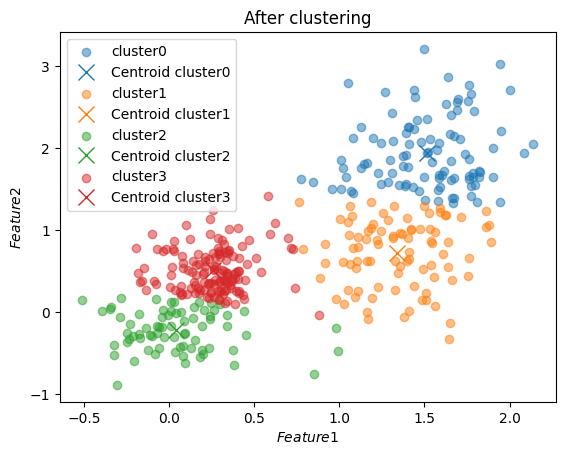

In [422]:
def initialize_centroids(K, num_features):
    return np.zeros((K, num_features))

def update_cluster(X, centroids):
    # Assign clusters
    r = np.zeros((N,K)) # Initialize r as a zero matrix  (300, 4)
    distances = np.zeros((N,K))
    for i in range(N):
        for k in range(K):
            distances[i,k] = np.sum((X[i] - centroids[k])**2)
    nearest_centroid = np.argmin(distances, axis=1)
    # Assign 1 to the nearest cluster in r
    r[np.arange(N), nearest_centroid] = 1
    return r, nearest_centroid, distances

def update_centroid(X, r, centroids):
    new_centroids = np.zeros((K, num_features))
    for k in range(K):
        # Check if the cluster has any points assigned
        if np.sum(r[:, k]) > 0:
            # Update centroid
            for i in range(N):
                new_centroids[k] += r[i,k]*X[i]
            new_centroids[k] /= np.sum(r[:,k])
        else:
            new_centroids[k] = centroids[k]
    return new_centroids

def kmeans(X, K, max_iters=100, epsilon=1e-6):
    N = X.shape[0]
    # Initialize the centroids to zero
    centroids = initialize_centroids(K, num_features)
    J = 1e6 # Arbitrary large number
    for iter in range(max_iters):
        r, nearest_centroid, distances = update_cluster(X,centroids)
        new_centroids = update_centroid(X, r, centroids)
        new_J = 0
        for i in range(N):
            for k in range(K):
                new_J += r[i,k]*distances[i,k]
        if np.abs((new_J - J)/new_J) < epsilon:
            break
        centroids = new_centroids
        J = new_J
        print('Iter :', iter, 'J : ', J)
    return nearest_centroid, centroids

nearest_centroid, centroids = kmeans(X, K)

plt.figure(1)
for i in range(K):
    plt.scatter(X[nearest_centroid == i, 0], X[nearest_centroid == i, 1], alpha = 0.5, label=f'cluster{i}')
    plt.plot(centroids[i, 0], centroids[i, 1], 'x', markersize=12, label=f'Centroid cluster{i}')
plt.legend()
plt.title("After clustering")
plt.xlabel(r'$Feature1$')
plt.ylabel(r'$Feature2$')
plt.show()
